# 09 — 변수 선택 재설계 (도메인 그룹핑 + 예측 최적화 + 성능 분포 정당화)

> 기말 플랜 `docs/final_presentation_plan.md` **§2.6** 구현 · 교수님 피드백 **F1·F3·F4** 응답
> **프로젝트 우선순위: 예측 1순위** — 변수 선택을 SHAP(해석)이 아니라 **성능 분포**로 정당화

## 목표
1. **(F3)** 후보를 **5개 도메인 그룹**으로 묶고 대표 변수 선정
2. **(F1)** **변수 제거가 해로운가** — 전체 vs 축소 vs 그룹대표 ablation
3. **(⑥)** 성능 분포 정당화: (a) 랜덤 서브셋 벤치마크, (b) 변수별 한계기여
4. 예측/해석 후보셋 확정 → `data/processed/features_v3_candidate.csv`

## ⭐ 순정 파이프라인 사용 (왜곡 방지)
- eval = **16d와 동일한** XGBoost(q50)·RobustScaler·3-fold walk-forward. **모델을 바꾸지 않고 변수집합만** 바꾼다.
- raw 변수 → `{var}` + `{var}__lag/__rmean/__rstd` 컬럼으로 확장 (162피처 공간).
- **162는 XGBoost 전용**. LSTM은 raw 변수를 시퀀스로 직접 학습 → 선택은 **raw 변수 레벨**(모델 무관)에서 하고, 확정 raw셋을 11에서 XGB(확장)·LSTM(raw)에 각각 적용.

## ⚠️ 정직성 가드 (plan §2.6 ⑥)
- 히스토그램은 **선택의 사후 검증용**이지 *선택 도구 아님* (최고 서브셋 cherry-pick = data snooping)
- 전체 변수집합을 1차로 두고, 분포·LOO는 보조 증거

---

## 0. 환경 설정

In [1]:
# === 의존성 체크 + import ===
import importlib.util, subprocess, sys
REQUIRED = {'xgboost':'xgboost','sklearn':'scikit-learn','matplotlib':'matplotlib','seaborn':'seaborn'}
for _imp, _pip in REQUIRED.items():
    if importlib.util.find_spec(_imp) is None:
        print(f'  Installing {_pip} ...'); subprocess.check_call([sys.executable,'-m','pip','install','-q',_pip])

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import RobustScaler
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR  = PROJECT_ROOT / 'reports' / 'figures' / 'v3'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42; np.random.seed(SEED)
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 180)
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: C:\Users\dongs\Desktop\머신러닝\머신러닝 기말 팀플\macro-bond-forecast


---

## 1. 순정 데이터 + 파이프라인 설정 (16d 동일)

`features_v2_no_leak.csv` = 14 raw(9 base + 5 파생) + 162 lag/rolling 확장 + `delta_y_bp`(타겟)

In [2]:
DF = pd.read_csv(DATA_DIR/'processed'/'features_v2_no_leak.csv',
                 index_col='date', parse_dates=['date']).sort_index()
TARGET = 'delta_y_bp'
ALL_FEATURE_COLS = [c for c in DF.columns if c != TARGET]
RAW_VARS = [c for c in ALL_FEATURE_COLS if '__' not in c]     # 14 raw (선택 단위)

# 16d 와 동일한 walk-forward fold + q50 하이퍼파라미터
FOLDS = [
    {'name':'fold1','train':('2010-01-01','2017-12-31'),'val':('2018-01-01','2019-12-31'),'test':('2020-01-01','2020-12-31')},
    {'name':'fold2','train':('2010-01-01','2019-12-31'),'val':('2020-01-01','2020-12-31'),'test':('2021-01-01','2022-12-31')},
    {'name':'fold3','train':('2010-01-01','2021-12-31'),'val':('2022-01-01','2022-12-31'),'test':('2023-01-01','2025-12-31')},
]
XGB_Q50 = dict(objective='reg:quantileerror', quantile_alpha=0.5,
               n_estimators=400, max_depth=4, learning_rate=0.05,
               early_stopping_rounds=50, tree_method='hist', random_state=42, verbosity=0)

print('전체 피처:', len(ALL_FEATURE_COLS), '| raw 변수:', len(RAW_VARS))
print('RAW_VARS:', RAW_VARS)

전체 피처: 162 | raw 변수: 14
RAW_VARS: ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'kospi', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']


---

## 2. 도메인 5개 그룹 정의 (F3 · plan §2.6①)

> VIF로 '제거'가 아니라, **경제 채널로 묶은 뒤 대표를 선택**. (교수님 피드백 핵심)

In [3]:
GROUPS = {
    'G1 글로벌금리':     ['us_treasury_10y','delta_us10y_t1','us_fed_funds','us_breakeven_10y'],
    'G2 한미연계/EM':    ['spread_10y_t1','dxy','delta_dxy_t1'],
    'G3 국내기간구조/정책':['kr_treasury_3y','kr_base_rate'],   # 복원후보 kr_5y/1y는 feature-eng 재실행 필요(TODO)
    'G4 위험심리':       ['vix','delta_vix_t1','sp500','kospi'],   # kospi는 Granger 제외(아래 §3) — 채널 개념상 여기 소속
    'G5 위기레짐':       ['crisis_dummy'],
}
REP = {'G1 글로벌금리':'delta_us10y_t1','G2 한미연계/EM':'spread_10y_t1',
       'G3 국내기간구조/정책':'kr_treasury_3y','G4 위험심리':'delta_vix_t1','G5 위기레짐':'crisis_dummy'}

rows=[]
for g,m in GROUPS.items():
    avail=[x for x in m if x in RAW_VARS]; miss=[x for x in m if x not in RAW_VARS]
    rows.append({'그룹':g,'대표':REP[g],'배정(확보)':', '.join(avail),'누락':', '.join(miss) or '-'})
print(pd.DataFrame(rows).to_string(index=False))
assigned=set(sum(GROUPS.values(),[])); print('\n그룹 미배정 raw:', [v for v in RAW_VARS if v not in assigned])
print('※ kospi(G4)는 Granger p=0.57로 v3 예측셋에서 제외 — 채널 개념상 위치만 표기.')

          그룹             대표                                                          배정(확보) 누락
    G1 글로벌금리 delta_us10y_t1 us_treasury_10y, delta_us10y_t1, us_fed_funds, us_breakeven_10y  -
  G2 한미연계/EM  spread_10y_t1                                spread_10y_t1, dxy, delta_dxy_t1  -
G3 국내기간구조/정책 kr_treasury_3y                                    kr_treasury_3y, kr_base_rate  -
     G4 위험심리   delta_vix_t1                                 vix, delta_vix_t1, sp500, kospi  -
     G5 위기레짐   crisis_dummy                                                    crisis_dummy  -

그룹 미배정 raw: []
※ kospi(G4)는 Granger p=0.57로 v3 예측셋에서 제외 — 채널 개념상 위치만 표기.


---

## 3. 변수집합 정의 (F1 ablation · plan §2.6②)

> **kospi는 Granger p=0.57로 제외**(VIF 1.11로 공선 문제는 아님). 제거가 무해함은 측정으로 확인됨 — *kospi 포함 0.605 → 제외 0.614* (오히려 미세 ↑). 따라서 v3 예측셋은 **kospi 제외 13개**로 시작한다.

ablation은 **"v3에서 더 줄이면 해로운가"** 를 본다:

- **★ v3 (13)**: kospi 제외한 우리 예측셋 (기준)
- **과도 축소 (12)**: v3에서 sp500(vix와 r=−0.73)까지 추가 제거 — "더 빼면 해로운가"
- **그룹 대표 (5)**: 도메인 대표 (최소·해석 친화)

가설: `v3(13) > 과도축소(12)` (sp500까지 빼면 해로움) **그리고** 잘 고른 `그룹대표(5) > 과도축소(12)` (막무가내 축소보다 도메인 선택이 낫다).

In [4]:
# kospi: Granger p=0.57로 처음부터 제외 의도 → v3 예측셋에서 제거 (아래 ablation·LOO에서 무해 확인)
SET_V3         = [v for v in RAW_VARS if v != 'kospi']                 # 13 — ★ 우리 v3 예측셋
SET_PLUS_KOSPI = list(RAW_VARS)                                       # 14 — kospi까지 포함(추가 효과 확인용)
SET_MIN_SP500  = [v for v in RAW_VARS if v not in ('kospi','sp500')]  # 12 — 과도 축소(해로움 확인용)
SET_GROUPREP   = [REP[g] for g in GROUPS if REP[g] in SET_V3]         # 5  — 그룹 대표(해석용)

CAND_VARS = SET_V3   # 후보 변수 풀 = kospi 제외 13개 (히스토그램·LOO 기준)

for nm, s in [('V3(우리,13)', SET_V3), ('+kospi(14)', SET_PLUS_KOSPI),
              ('-sp500(12)', SET_MIN_SP500), ('GROUPREP(5)', SET_GROUPREP)]:
    print(f'{nm:13s} ({len(s):2d} raw):', s)

V3(우리,13)     (13 raw): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']
+kospi(14)    (14 raw): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'kospi', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']
-sp500(12)    (12 raw): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']
GROUPREP(5)   ( 5 raw): ['delta_us10y_t1', 'spread_10y_t1', 'kr_treasury_3y', 'delta_vix_t1', 'crisis_dummy']


---

## 4. 순정 eval 함수 — raw셋 → 162공간 확장 → 16d XGBoost(q50)

> 모델·fold·스케일러 전부 16d와 동일. raw 변수집합만 바꿔 walk-forward dir acc 측정 (왜곡 없음).

In [5]:
def expand(raw_set):
    """raw 변수 → 그 변수의 base + __lag/__rmean/__rstd 컬럼 전체."""
    cols=[]
    for v in raw_set:
        cols += [c for c in ALL_FEATURE_COLS if c==v or c.startswith(v+'__')]
    return cols

def eval_canonical(raw_set, return_folds=False):
    feat = expand(raw_set)
    if not feat: return (np.nan, []) if return_folds else np.nan
    accs=[]
    for fold in FOLDS:
        sl = lambda p: DF.loc[fold[p][0]:fold[p][1]]
        Xtr, Xval, Xte = sl('train')[feat], sl('val')[feat], sl('test')[feat]
        ytr, yval, yte = sl('train')[TARGET], sl('val')[TARGET], sl('test')[TARGET]
        sc = RobustScaler().fit(Xtr)
        m = xgb.XGBRegressor(**XGB_Q50)
        m.fit(sc.transform(Xtr), ytr, eval_set=[(sc.transform(Xval), yval)], verbose=False)
        pred = m.predict(sc.transform(Xte)); yv = yte.values
        mask=(np.sign(pred)!=0)&(np.sign(yv)!=0)
        accs.append(float((np.sign(pred[mask])==np.sign(yv[mask])).mean()))
    return (float(np.mean(accs)), accs) if return_folds else float(np.mean(accs))

# 스모크 테스트 (순정 — v3 13변수, 중간 ~0.61 근처여야 정상)
acc, folds = eval_canonical(SET_V3, return_folds=True)
print('V3(13) dir acc (순정 q50):', round(acc,4), '| fold별:', [round(a,3) for a in folds])

V3(13) dir acc (순정 q50): 0.6137 | fold별: [0.61, 0.591, 0.64]


---

## 5. ablation — FULL vs REDUCED vs GROUPREP (F1)

                     집합  n_raw  n_feat  dir_acc
★ v3 우리\n(13, kospi 제외)     13     150 0.613654
 과도 축소\n(12, sp500도 제거)     12     138 0.582443
            그룹 대표\n(5개)      5      54 0.597406


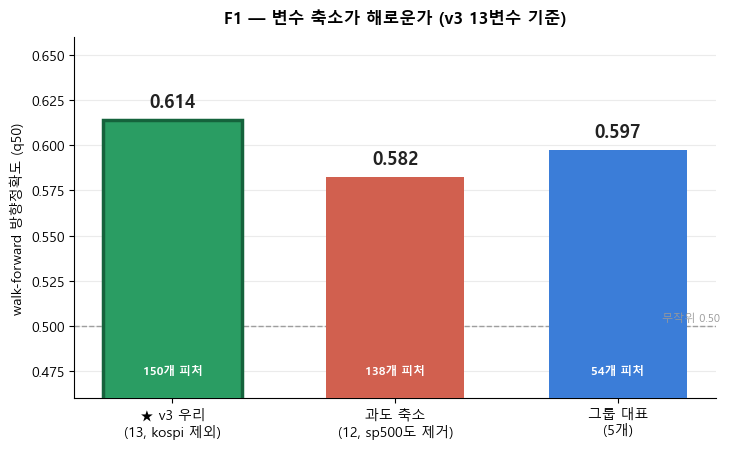

In [6]:
# === 공통 발표 팔레트 ===
C_FULL, C_RED, C_REP = '#3b7dd8', '#d1604f', '#2a9d63'   # 비교=파랑 · 과도축소=빨강 · 우리=초록
C_RAND, C_NONSEL     = '#c9ced6', '#e0a458'              # 랜덤 전체풀=회색 · 비선택풀=주황

# v3(13)을 기준으로: 우리 → 과도축소(sp500도 제거) → 그룹대표
ablation = pd.DataFrame({
    '집합':['★ v3 우리\n(13, kospi 제외)','과도 축소\n(12, sp500도 제거)','그룹 대표\n(5개)'],
    'sets':[SET_V3, SET_MIN_SP500, SET_GROUPREP],
})
ablation['n_raw']  = ablation['sets'].apply(len)
ablation['n_feat'] = ablation['sets'].apply(lambda s: len(expand(s)))
ablation['dir_acc']= ablation['sets'].apply(eval_canonical)
print(ablation[['집합','n_raw','n_feat','dir_acc']].to_string(index=False))

fig,ax=plt.subplots(figsize=(7.4,4.6))
colors=[C_REP, C_RED, C_FULL]                 # v3=초록(강조) · 과도축소=빨강 · 그룹대표=파랑
bars=ax.bar(ablation['집합'], ablation['dir_acc'], color=colors, width=0.62, zorder=3)
bars[0].set_edgecolor('#15633c'); bars[0].set_linewidth(2.5)   # 우리 셋 테두리 강조
for b,acc,nf in zip(bars, ablation['dir_acc'], ablation['n_feat']):
    cx=b.get_x()+b.get_width()/2
    ax.text(cx, acc+0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold', color='#222')
    ax.text(cx, 0.472, f'{nf}개 피처', ha='center', va='bottom', fontsize=8.5, color='white', fontweight='bold')
ax.axhline(0.5, color='#999', ls='--', lw=1, zorder=1);   ax.text(2.46,0.503,'무작위 0.50',fontsize=8,color='#999',ha='right')
ax.set_ylabel('walk-forward 방향정확도 (q50)'); ax.set_ylim(0.46,0.66)
ax.set_title('F1 — 변수 축소가 해로운가 (v3 13변수 기준)', fontweight='bold', fontsize=12, pad=10)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='y', alpha=0.25, zorder=0)
plt.tight_layout(); plt.savefig(FIG_DIR/'09_ablation.png', dpi=150, bbox_inches='tight'); plt.show()
# 해석: v3(13) > 과도축소(12) → sp500까지 빼면 해롭다. 그룹대표(5)는 12보다 높음 → 잘 고른 소수가 막무가내 축소보다 낫다.

---

## 6. ⑥(a) 서브셋 벤치마크 분포 (순정, **전수**) — 두 비교 풀 겹쳐 표시

후보가 13개로 줄어 경우의 수가 작아졌으므로 **샘플링 대신 전수(全數) 평가**한다 (노이즈·SEED 의존성 제거 → "모든 조합을 다 시험했다"). 도메인 선택(대표 5개) 위치를 두 분포에 동시 표시:

- **후보 13개 → 5개 전수 (C(13,5)=1287)**: 가능한 모든 5변수 조합. 우리 변수와 겹치는 조합 포함.
- **비선택 8개 → 5개 전수 (C(8,5)=56)**: "우리가 **버린** 변수들로 만든 모든 5개 조합". 겹침 없음 → *"대표를 잘 골랐는가"* 직접 답.

> ⚠️ 검증용 분포이지 **선택 도구가 아니다**(최고 서브셋 cherry-pick = data snooping). 전수라 CPU 수 분 소요.

  [후보 전수] 200/1287 ...


  [후보 전수] 400/1287 ...


  [후보 전수] 600/1287 ...


  [후보 전수] 800/1287 ...


  [후보 전수] 1000/1287 ...


  [후보 전수] 1200/1287 ...



우리 대표 5개 dir acc = 0.5974
  · 후보 13개 풀 전수(1285=C(13,5)) 대비: 81.4% 능가  (상위 18.6% · 중앙값 0.525)
  · 비선택 8개 풀 전수(56=C(8,5))  대비: 100.0% 능가  (상위 0.0% · 중앙값 0.504)


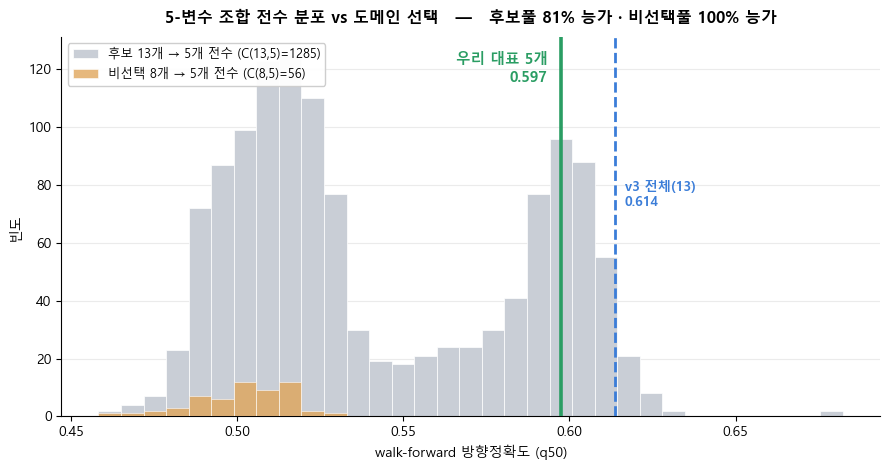

In [7]:
from itertools import combinations
k    = len(SET_GROUPREP)                       # 부분집합 크기 = 대표 수 (5)
our  = eval_canonical(SET_GROUPREP)
v3   = eval_canonical(SET_V3)                  # 우리 v3 전체(13)

# --- 분포 1: 후보 13개에서 5개 — 전수 C(13,5)=1287 (샘플링 X → 노이즈·SEED 의존성 제거) ---
combos_all = list(combinations(CAND_VARS, k))
scores_all=[]
for j,cols in enumerate(combos_all):
    s=eval_canonical(list(cols))
    if not np.isnan(s): scores_all.append(s)
    if (j+1)%200==0: print(f'  [후보 전수] {j+1}/{len(combos_all)} ...')
scores_all=np.array(scores_all)

# --- 분포 2: 우리가 '안 고른' 8개에서 5개 — 전수 C(8,5)=56 ---
NON_SEL=[v for v in CAND_VARS if v not in SET_GROUPREP]
combos_non=list(combinations(NON_SEL, k))
scores_non=[]
for j,cols in enumerate(combos_non):
    s=eval_canonical(list(cols))
    if not np.isnan(s): scores_non.append(s)
scores_non=np.array(scores_non)

beat_all=float((scores_all<our).mean()*100)    # 우리 대표가 능가한 비율(%)
beat_non=float((scores_non<our).mean()*100)
print(f'\n우리 대표 5개 dir acc = {our:.4f}')
print(f'  · 후보 13개 풀 전수({len(scores_all)}=C(13,5)) 대비: {beat_all:.1f}% 능가  (상위 {100-beat_all:.1f}% · 중앙값 {np.median(scores_all):.3f})')
print(f'  · 비선택 8개 풀 전수({len(scores_non)}=C(8,5))  대비: {beat_non:.1f}% 능가  (상위 {100-beat_non:.1f}% · 중앙값 {np.median(scores_non):.3f})')

# --- 두 분포를 한 그림에 겹쳐 표시 ---
fig,ax=plt.subplots(figsize=(9,4.8))
lo=min(scores_all.min(),scores_non.min())-0.006; hi=max(scores_all.max(),scores_non.max())+0.006
bins=np.linspace(lo,hi,34)
ax.hist(scores_all, bins=bins, color=C_RAND, edgecolor='white', lw=0.5, zorder=2,
        label=f'후보 13개 → 5개 전수 (C(13,5)={len(scores_all)})')
ax.hist(scores_non, bins=bins, color=C_NONSEL, alpha=0.78, edgecolor='white', lw=0.5, zorder=3,
        label=f'비선택 8개 → 5개 전수 (C(8,5)={len(scores_non)})')
ax.axvline(our, color=C_REP,  lw=2.6, zorder=5)
ax.axvline(v3,  color=C_FULL, lw=2.0, ls='--', zorder=5)
ymax=ax.get_ylim()[1]
ax.annotate(f'우리 대표 5개\n{our:.3f}', xy=(our,ymax*0.96), xytext=(our-0.004,ymax*0.96),
            color=C_REP, fontweight='bold', fontsize=10.5, ha='right', va='top')
ax.annotate(f'v3 전체(13)\n{v3:.3f}', xy=(v3,ymax*0.62), xytext=(v3+0.003,ymax*0.62),
            color=C_FULL, fontweight='bold', fontsize=9.5, ha='left', va='top')
ax.set_xlabel('walk-forward 방향정확도 (q50)'); ax.set_ylabel('빈도')
ax.set_title(f'5-변수 조합 전수 분포 vs 도메인 선택   —   후보풀 {beat_all:.0f}% 능가 · 비선택풀 {beat_non:.0f}% 능가',
             fontweight='bold', fontsize=11.5, pad=10)
ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='y', alpha=0.25, zorder=0)
plt.tight_layout(); plt.savefig(FIG_DIR/'09_random_subset_hist.png', dpi=150, bbox_inches='tight'); plt.show()

---

## 7. ⑥(b) 변수별 한계 기여 (LOO)

전체(FULL)에서 raw 1개씩 제거 → dir acc 하락폭 = 그 변수의 한계 가치.

v3(13) dir acc: 0.6137
              변수  제거시 dir_acc   Δ(기여)
  delta_us10y_t1       0.5103  0.1034
           sp500       0.5824  0.0312
  kr_treasury_3y       0.5852  0.0285
             dxy       0.5921  0.0215
             vix       0.5924  0.0212
 us_treasury_10y       0.5929  0.0207
us_breakeven_10y       0.5935  0.0202
    delta_dxy_t1       0.5955  0.0182
    kr_base_rate       0.5977  0.0159
   spread_10y_t1       0.6057  0.0080
    us_fed_funds       0.6104  0.0032
    delta_vix_t1       0.6137 -0.0001
    crisis_dummy       0.6157 -0.0020


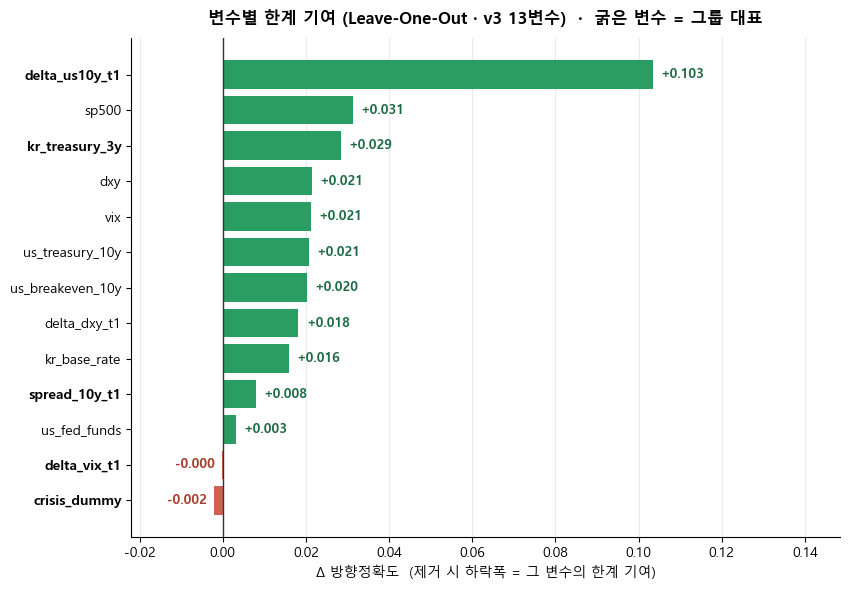

In [8]:
base_acc = eval_canonical(SET_V3)          # 우리 v3 13변수 기준
loo=[]
for v in SET_V3:
    acc=eval_canonical([x for x in SET_V3 if x!=v])
    loo.append({'변수':v,'제거시 dir_acc':round(acc,4),'Δ(기여)':round(base_acc-acc,4)})
loo_df=pd.DataFrame(loo).sort_values('Δ(기여)',ascending=False)
print('v3(13) dir acc:',round(base_acc,4)); print(loo_df.to_string(index=False))

plot_df=loo_df.sort_values('Δ(기여)', ascending=True)   # barh: 큰 기여가 위로
fig,ax=plt.subplots(figsize=(8.6,6))
colors=[C_REP if v>=0 else C_RED for v in plot_df['Δ(기여)']]
ytick_w=['bold' if v in SET_GROUPREP else 'normal' for v in plot_df['변수']]   # 그룹 대표 굵게
bars=ax.barh(plot_df['변수'], plot_df['Δ(기여)'], color=colors, zorder=3)
for b,v in zip(bars, plot_df['Δ(기여)']):
    ax.text(v+(0.0018 if v>=0 else -0.0018), b.get_y()+b.get_height()/2, f'{v:+.3f}',
            va='center', ha='left' if v>=0 else 'right', fontsize=9.5, fontweight='bold',
            color='#1c6b43' if v>=0 else '#a83b2c')
for t,w in zip(ax.get_yticklabels(), ytick_w):
    t.set_fontweight(w)
ax.axvline(0, color='#333', lw=1.0, zorder=4)
xmin,xmax=plot_df['Δ(기여)'].min(),plot_df['Δ(기여)'].max()
ax.set_xlim(xmin-0.02, xmax+0.045)
ax.set_xlabel('Δ 방향정확도  (제거 시 하락폭 = 그 변수의 한계 기여)')
ax.set_title('변수별 한계 기여 (Leave-One-Out · v3 13변수)  ·  굵은 변수 = 그룹 대표',
             fontweight='bold', fontsize=12, pad=10)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='x', alpha=0.25, zorder=0)
plt.tight_layout(); plt.savefig(FIG_DIR/'09_loo.png', dpi=150, bbox_inches='tight'); plt.show()
# Δ<0 변수(제거가 오히려 도움)는 해석 주의: 공선 파트너에 기여가 흡수됐을 수 있음(교수님 F2).

---

## 8. 결론 — 예측/해석 후보셋 확정

> 도메인 + ablation + 분포 종합. 분포 최고점 cherry-pick 금지.

- **예측(PRED_SET) = 13 raw** (kospi 제외). kospi는 Granger p=0.57로 제외했고 ablation에서 무해 확인. 단 sp500까지 빼는 과도 축소는 안 함.
- **해석(INTERP_SET) = 그룹 대표 5개**.

In [9]:
PRED_SET   = SET_V3        # 예측용: 13 raw (kospi 제외 — 무해 확인). 과도 축소는 안 함.
INTERP_SET = SET_GROUPREP  # 해석용: 그룹 대표 5개

print('PRED_SET  (%d raw):'%len(PRED_SET), PRED_SET)
print('INTERP_SET(%d raw):'%len(INTERP_SET), INTERP_SET)

# 확정 raw셋의 162-확장 컬럼 + 타겟 저장 (11에서 사용)
out_cols = expand(PRED_SET) + [TARGET]
out = DF[out_cols].copy()
out_path = DATA_DIR/'processed'/'features_v3_candidate.csv'
out.to_csv(out_path)
print('\n💾 저장:', out_path.relative_to(PROJECT_ROOT), out.shape, '| raw:', PRED_SET)

PRED_SET  (13 raw): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']
INTERP_SET(5 raw): ['delta_us10y_t1', 'spread_10y_t1', 'kr_treasury_3y', 'delta_vix_t1', 'crisis_dummy']



💾 저장: data\processed\features_v3_candidate.csv (3725, 151) | raw: ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'sp500', 'dxy', 'spread_10y_t1', 'delta_us10y_t1', 'delta_vix_t1', 'delta_dxy_t1', 'crisis_dummy']


---

## 9. 다음 단계

- [ ] §5 ablation / §6 분포 / §7 LOO 검토 후 **PRED_SET·INTERP_SET 최종 확정**
- [ ] (선택) kr_5y/1y 진짜 VIF-복원 테스트 → feature-eng 재실행 필요 (현재 파일엔 kr_3y만 확장됨)
- [ ] `11_v3_results.ipynb` — 확정 raw셋으로 **XGBoost(162확장)·LSTM(raw 시퀀스)** full 재실행 + DM test
- [ ] `12_pred_interval_v3.ipynb` — v3 예측구간(§3.1)

### 정직성 메모
- eval은 16d와 동일 모델(q50·fold·scaler) — 변수집합만 변경(왜곡 없음)
- 분포·LOO는 검증용, 선택은 도메인 1차
- 실제 v2가 kospi 포함 9 base를 다 썼다는 사실 → 발표 변수선택 서사 정정 필요(plan §2.6)
